# 02. 結果 — ローリングバックテストの評価

`scripts/run_backtest.py` が出力した予測(`outputs/predictions_*.parquet`)を評価する。

* 評価期間: 2017-07 〜 2018-06 の 12 ヶ月(毎月、その月より前の全データで再学習)
* 予測対象: 1 / 3 / 6 / 12 / 24 時間先の温度変化量 → 温度に戻して評価
* 品質フラグ行(31 日の前方補完・センサ欠測)は評価から除外

モデル:

| 名前 | 説明 |
|---|---|
| persistence | 「N 時間後も今と同じ」。現状の閾値監視に相当 |
| seasonal_naive | 「昨日の同時刻と同じ」 |
| lgbm_no_load | LightGBM、温度の過去値 + 時刻特徴のみ |
| **lgbm** | LightGBM、上記 + 負荷 6 変数の過去値(本命) |
| lgbm_oracle_load | 参考: 未来の負荷も入力(実運用不可の上限値) |

In [1]:
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ettpoc.evaluate import event_metrics, regression_metrics, rise_event, threshold_event

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
FIG = "../reports/figures"
OUT = "../outputs"
DATASETS = ["ETTh1", "ETTh2"]
ORDER = ["persistence", "seasonal_naive", "lgbm_no_load", "lgbm", "lgbm_oracle_load"]
COLORS = dict(zip(ORDER, ["gray", "silver", "C0", "C3", "C1"]))
preds = pd.concat([pd.read_parquet(f"{OUT}/predictions_{n}.parquet") for n in DATASETS], ignore_index=True)
preds["month"] = preds.date.dt.to_period("M")
print(preds.groupby("dataset").size())

dataset
ETTh1    206420
ETTh2    210670
dtype: int64


## 1. 予測精度 — h2 では 12 時間先まで persistence を 55〜60% 改善、h1 は 10〜20%

* どちらの設備でも LightGBM は persistence に勝つが、**改善幅は設備で大きく違う**(EDA の予測可能性の差そのもの)。
* **24 時間先は全モデルが persistence と同等** → 1 日先の温度は過去の温度・負荷からは決まらない(外気温など外部要因)。
* 負荷ラグの有無(lgbm vs lgbm_no_load)でほぼ差が無く、**未来の負荷を与えても(oracle)改善しない**。温度変動の主因は負荷ではない。

In [2]:
rows = []
for (d, h, m), g in preds.groupby(["dataset", "horizon", "model"]):
    rows.append({"dataset": d, "horizon": h, "model": m, **regression_metrics(g.delta_true, g.delta_pred)})
metrics = pd.DataFrame(rows)
mae = metrics.pivot_table(index=["dataset", "model"], columns="horizon", values="mae").reindex(ORDER, level=1)
skill = mae.copy()
for d in DATASETS:
    skill.loc[d] = (1 - mae.loc[d] / mae.loc[(d, "persistence")]).values
print("MAE [°C]"); display(mae.round(2))
print("Skill vs persistence (1 - MAE/MAE_persistence)"); display(skill.round(2))
mae.round(3).to_csv(f"{OUT}/table_mae.csv"); skill.round(3).to_csv(f"{OUT}/table_skill.csv")

MAE [°C]


horizon                     1     3     6     12    24
dataset model                                         
ETTh1   persistence       0.50  0.91  1.32  1.73  1.74
        seasonal_naive    1.75  1.75  1.75  1.75  1.74
        lgbm_no_load      0.47  0.78  1.06  1.39  1.72
        lgbm              0.46  0.75  1.04  1.37  1.73
        lgbm_oracle_load  0.46  0.75  1.02  1.36  1.71
ETTh2   persistence       0.91  2.52  4.39  6.02  3.12
        seasonal_naive    3.16  3.16  3.16  3.16  3.12
        lgbm_no_load      0.38  1.02  1.77  2.60  3.03
        lgbm              0.38  1.03  1.82  2.65  3.06
        lgbm_oracle_load  0.39  1.03  1.80  2.60  3.08

Skill vs persistence (1 - MAE/MAE_persistence)


horizon                     1     3     6     12    24
dataset model                                         
ETTh1   persistence       0.00  0.00  0.00  0.00  0.00
        seasonal_naive   -2.52 -0.93 -0.33 -0.01  0.00
        lgbm_no_load      0.06  0.14  0.20  0.20  0.01
        lgbm              0.07  0.17  0.21  0.21  0.01
        lgbm_oracle_load  0.07  0.17  0.23  0.21  0.02
ETTh2   persistence       0.00  0.00  0.00  0.00  0.00
        seasonal_naive   -2.49 -0.25  0.28  0.48  0.00
        lgbm_no_load      0.58  0.60  0.60  0.57  0.03
        lgbm              0.58  0.59  0.58  0.56  0.02
        lgbm_oracle_load  0.57  0.59  0.59  0.57  0.01

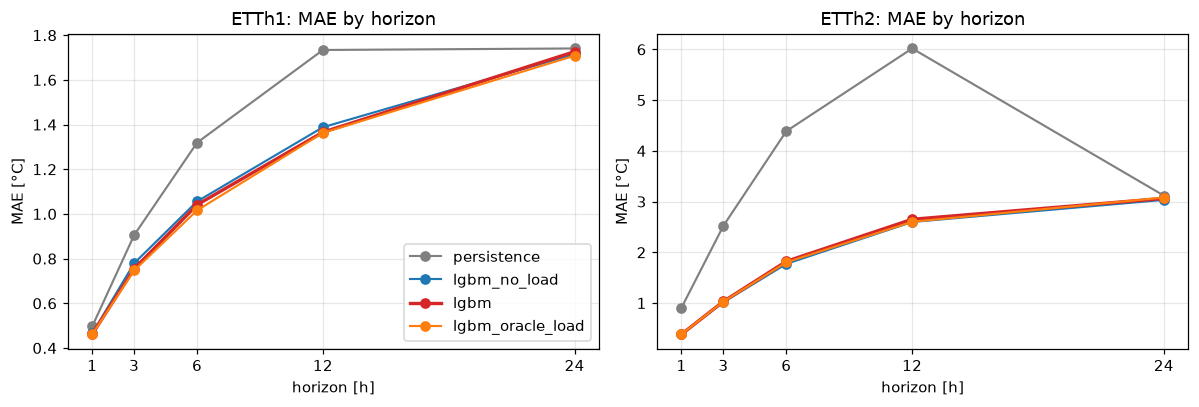

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, d in zip(axes, DATASETS):
    for m in ORDER:
        if m == "seasonal_naive": continue
        ax.plot(mae.columns, mae.loc[(d, m)], "o-", c=COLORS[m], label=m, lw=2.2 if m == "lgbm" else 1.4)
    ax.set_title(f"{d}: MAE by horizon"); ax.set_xlabel("horizon [h]"); ax.set_ylabel("MAE [°C]"); ax.set_xticks(mae.columns)
axes[0].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/res_mae_by_horizon.png"); plt.show()

## 2. 業務指標 — 高温リスク警告としての性能

2 種類のイベントを「N 時間前に警告できたか」で評価する。閾値は設備ごとに評価年の上位 ~5〜7% に相当する値を仮置き。

| 設備 | 閾値超過イベント | 急上昇イベント |
|---|---|---|
| ETTh1 | OT > 20℃ | N 時間以内に +3℃ |
| ETTh2 | OT > 45℃ | N 時間以内に +5℃ |

* **検知率 (recall)**: 実際に起きたイベントのうち、事前に警告できた割合
* **適合率 (precision)**: 出した警告のうち本当に起きた割合(低いと「狼少年」になる)
* persistence = 「今の温度がそのまま続く」と仮定した判断 = 現状の閾値監視で得られる情報量。急上昇イベントは構造上 0% になる。

In [4]:
EVENTS = {"ETTh1": dict(thr=20, rise=3), "ETTh2": dict(thr=45, rise=5)}
rows = []
for (d, h, m), g in preds.groupby(["dataset", "horizon", "model"]):
    c = EVENTS[d]
    a, p = threshold_event(g.ot_now, g.delta_true, g.delta_pred, c["thr"])
    rows.append({"dataset": d, "event": f"OT>{c['thr']}°C", "horizon": h, "model": m, **event_metrics(a, p)})
    a, p = rise_event(g.delta_true, g.delta_pred, c["rise"])
    rows.append({"dataset": d, "event": f"rise≥{c['rise']}°C", "horizon": h, "model": m, **event_metrics(a, p)})
ev = pd.DataFrame(rows)
ev.to_csv(f"{OUT}/table_events.csv", index=False)
show = ev[ev.model.isin(["persistence", "lgbm"]) & ev.horizon.isin([3, 6, 12, 24])]
display(show.set_index(["dataset", "event", "horizon", "model"])[["n_events", "detected", "recall", "precision", "false_alarms", "f1"]].round(2))

n_events  detected  recall  precision  \
dataset event    horizon model                                                
ETTh1   OT>20°C  3       lgbm              605       575    0.95       0.89   
        rise≥3°C 3       lgbm               93         0    0.00        NaN   
        OT>20°C  3       persistence       605       542    0.90       0.90   
        rise≥3°C 3       persistence        93         0    0.00        NaN   
        OT>20°C  6       lgbm              605       561    0.93       0.86   
        rise≥3°C 6       lgbm              341        20    0.06       0.56   
        OT>20°C  6       persistence       605       518    0.86       0.86   
        rise≥3°C 6       persistence       341         0    0.00        NaN   
        OT>20°C  12      lgbm              605       522    0.86       0.86   
        rise≥3°C 12      lgbm              687       148    0.22       0.53   
        OT>20°C  12      persistence       605       495    0.82       0.82   
        rise≥3°C 12      persistence       687         0    0.00        NaN   
        OT>20°C  24      lgbm              605       513    0.85       0.84   
        rise≥3°C 24      lgbm              543        44    0.08       0.61   
        OT>20°C  24      persistence       605       502    0.83       0.83   
        rise≥3°C 24      persistence       543         0    0.00        NaN   
ETTh2   OT>45°C  3       lgbm              498       439    0.88       0.91   
        rise≥5°C 3       lgbm              904       608    0.67       0.80   
        OT>45°C  3       persistence       498       335    0.67       0.68   
        rise≥5°C 3       persistence       904         0    0.00        NaN   
        OT>45°C  6       lgbm              498       388    0.78       0.85   
        rise≥5°C 6       lgbm             1519      1199    0.79       0.75   
        OT>45°C  6       persistence       498       210    0.42       0.43   
        rise≥5°C 6       persistence      1519         0    0.00        NaN   
        OT>45°C  12      lgbm              498       350    0.70       0.80   
        rise≥5°C 12      lgbm             2188      1749    0.80       0.70   
        OT>45°C  12      persistence       498       108    0.22       0.22   
        rise≥5°C 12      persistence      2188         0    0.00        NaN   
        OT>45°C  24      lgbm              498       346    0.69       0.76   
        rise≥5°C 24      lgbm              732         0    0.00       0.00   
        OT>45°C  24      persistence       498       363    0.73       0.75   
        rise≥5°C 24      persistence       732         0    0.00        NaN   

                                      false_alarms    f1  
dataset event    horizon model                            
ETTh1   OT>20°C  3       lgbm                   71  0.92  
        rise≥3°C 3       lgbm                    0  0.00  
        OT>20°C  3       persistence            63  0.90  
        rise≥3°C 3       persistence             0  0.00  
        OT>20°C  6       lgbm                   93  0.89  
        rise≥3°C 6       lgbm                   16  0.11  
        OT>20°C  6       persistence            87  0.86  
        rise≥3°C 6       persistence             0  0.00  
        OT>20°C  12      lgbm                   85  0.86  
        rise≥3°C 12      lgbm                  130  0.31  
        OT>20°C  12      persistence           109  0.82  
        rise≥3°C 12      persistence             0  0.00  
        OT>20°C  24      lgbm                   98  0.84  
        rise≥3°C 24      lgbm                   28  0.14  
        OT>20°C  24      persistence           102  0.83  
        rise≥3°C 24      persistence             0  0.00  
ETTh2   OT>45°C  3       lgbm                   41  0.90  
        rise≥5°C 3       lgbm                  149  0.73  
        OT>45°C  3       persistence           160  0.67  
        rise≥5°C 3       persistence             0  0.00  
        OT>45°C  6       lgbm                   67  0

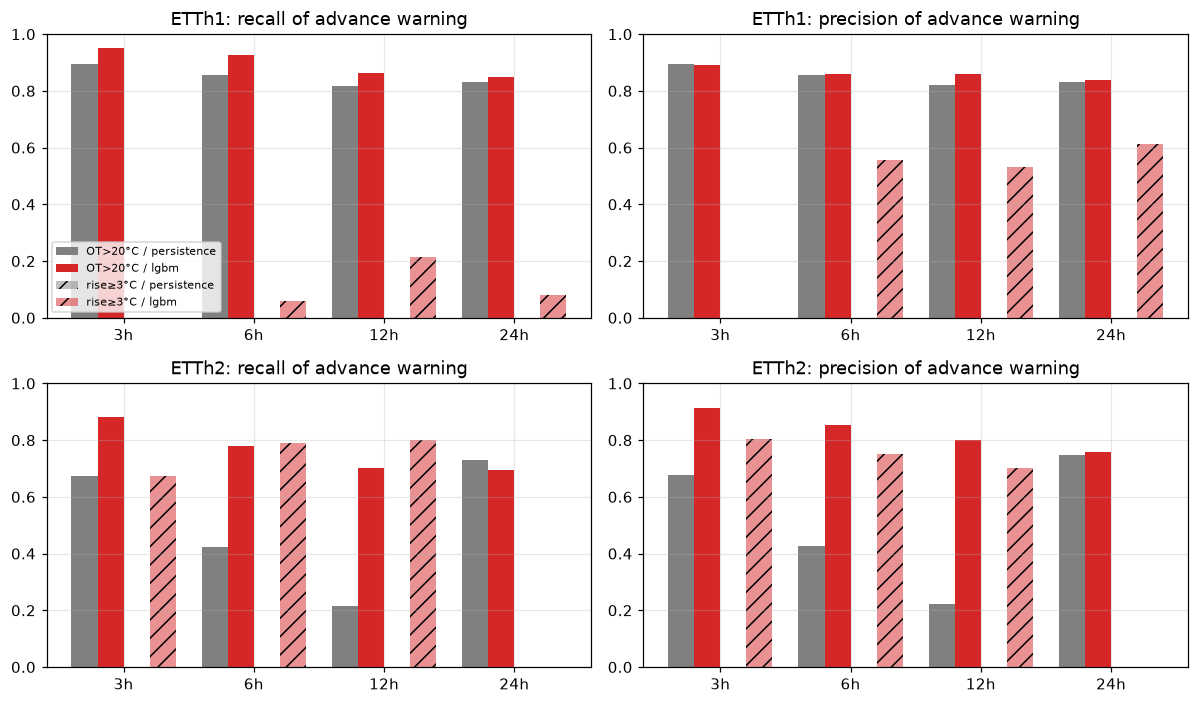

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for i, d in enumerate(DATASETS):
    for j, metric in enumerate(["recall", "precision"]):
        ax = axes[i, j]
        sub = ev[(ev.dataset == d) & (ev.model.isin(["persistence", "lgbm"]))]
        x = np.arange(4); w = 0.2
        for k, (evname, m) in enumerate([(e, mm) for e in sub.event.unique() for mm in ["persistence", "lgbm"]]):
            s = sub[(sub.event == evname) & (sub.model == m) & sub.horizon.isin([3, 6, 12, 24])].sort_values("horizon")
            ax.bar(x + (k - 1.5) * w, s[metric].fillna(0), w, color=COLORS[m], alpha=1 if "OT" in evname else 0.5,
                   hatch=None if "OT" in evname else "//", label=f"{evname} / {m}")
        ax.set_xticks(x); ax.set_xticklabels(["3h", "6h", "12h", "24h"]); ax.set_ylim(0, 1)
        ax.set_title(f"{d}: {metric} of advance warning")
        if i == 0 and j == 0: ax.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.savefig(f"{FIG}/res_event_metrics.png"); plt.show()

## 3. 季節による違い — 夏(高温期)でも改善は維持される

6 時間先の MAE を月別に見る。h2 は 5〜9 月に変動が大きく persistence の誤差が跳ね上がるが、LightGBM は年間を通して安定。

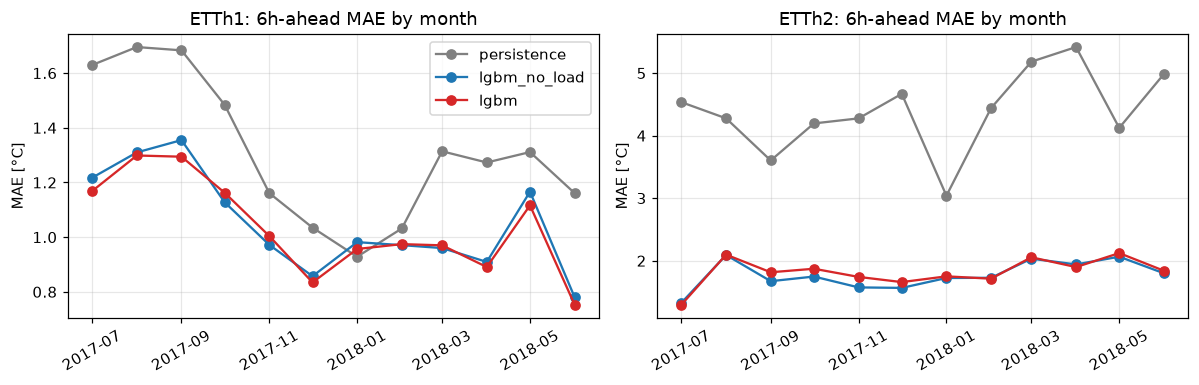

In [6]:
h6 = preds[preds.horizon == 6]
mm = h6.groupby(["dataset", "month", "model"]).apply(lambda g: np.mean(np.abs(g.delta_true - g.delta_pred))).unstack("model")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, d in zip(axes, DATASETS):
    t = mm.loc[d]
    for m in ["persistence", "lgbm_no_load", "lgbm"]:
        ax.plot(t.index.to_timestamp(), t[m], "o-", c=COLORS[m], label=m)
    ax.set_title(f"{d}: 6h-ahead MAE by month"); ax.set_ylabel("MAE [°C]"); ax.tick_params(axis="x", labelrotation=30)
axes[0].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/res_mae_by_month.png"); plt.show()

## 4. 予測の実例 — ETTh2、2017 年 7 月の 1 週間(6 時間先予測)

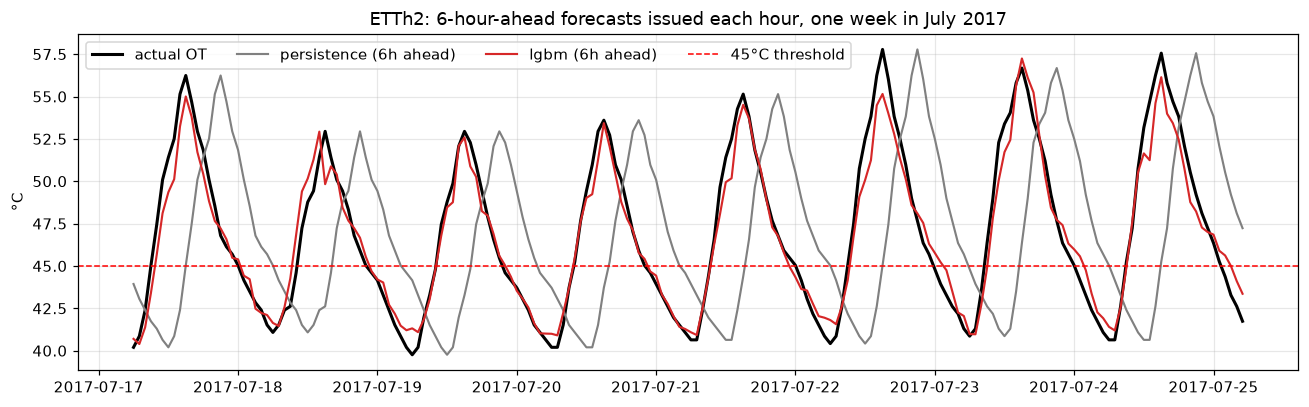

In [7]:
g = preds[(preds.dataset == "ETTh2") & (preds.horizon == 6)]
g = g[(g.date >= "2017-07-17") & (g.date < "2017-07-25")].sort_values("date").set_index("date")
fig, ax = plt.subplots(figsize=(12, 3.8))
act = g[g.model == "lgbm"]
ax.plot(act.index + pd.Timedelta(hours=6), act.ot_now + act.delta_true, "k-", lw=2, label="actual OT")
for m in ["persistence", "lgbm"]:
    s = g[g.model == m]
    ax.plot(s.index + pd.Timedelta(hours=6), s.ot_now + s.delta_pred, "-", c=COLORS[m], lw=1.4, label=f"{m} (6h ahead)")
ax.axhline(45, c="red", ls="--", lw=1, label="45°C threshold")
ax.set_title("ETTh2: 6-hour-ahead forecasts issued each hour, one week in July 2017"); ax.set_ylabel("°C"); ax.legend(loc="upper left", ncol=4)
plt.tight_layout(); plt.savefig(f"{FIG}/res_example_week.png"); plt.show()

## 5. 何が効いているか — 特徴量重要度(lgbm, 6h 先)

* 上位は温度の過去値・差分・ローリング統計と時刻特徴。**負荷変数はほぼ寄与しない**。
* h2 では `hour_sin/cos` と 24h 前後のラグが上位 → 日内周期の学習が改善の源泉。

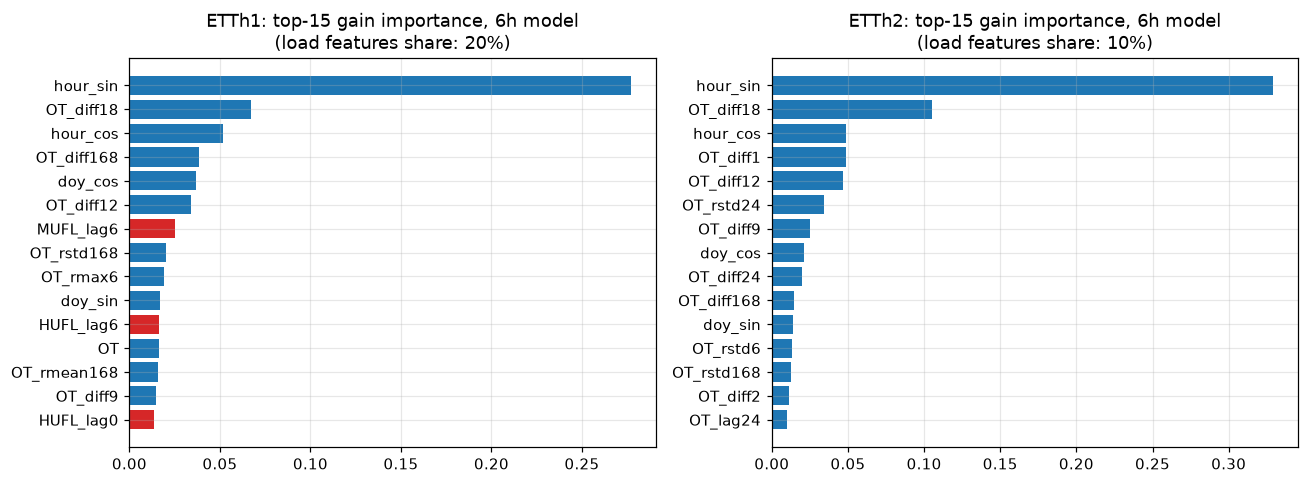

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, d in zip(axes, DATASETS):
    imps = pickle.load(open(f"{OUT}/importances_{d}.pkl", "rb"))[("lgbm", 6)]
    imp = pd.concat(imps, axis=1).mean(axis=1).sort_values(ascending=False)
    imp = imp / imp.sum()
    top = imp.head(15)[::-1]
    colors = ["C1" if any(top.index.str.startswith(c) for c in []) else ("C3" if any(k in i for k in ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]) else "C0") for i in top.index]
    ax.barh(top.index, top.values, color=colors)
    load_share = imp[[i for i in imp.index if any(k in i for k in ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"])]].sum()
    ax.set_title(f"{d}: top-15 gain importance, 6h model\n(load features share: {load_share:.0%})")
plt.tight_layout(); plt.savefig(f"{FIG}/res_importance.png"); plt.show()

## 6. 誤差の性質 — 大きな外しはどこで起きるか

6 時間先の残差(実測 − 予測)を時刻別に見る。h2 では午前中の昇温局面で残差の分散が大きく、**上昇の立ち上がりタイミング**が最も難しい。

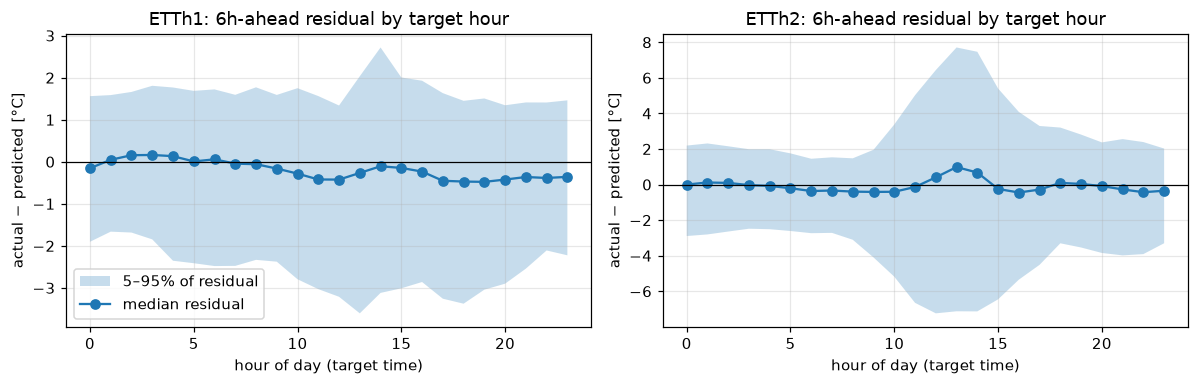

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, d in zip(axes, DATASETS):
    s = preds[(preds.dataset == d) & (preds.horizon == 6) & (preds.model == "lgbm")]
    res = (s.delta_true - s.delta_pred)
    tgt_hour = (s.date + pd.Timedelta(hours=6)).dt.hour
    q = res.groupby(tgt_hour).quantile([0.05, 0.5, 0.95]).unstack()
    ax.fill_between(q.index, q[0.05], q[0.95], alpha=0.25, label="5–95% of residual")
    ax.plot(q.index, q[0.5], "o-", label="median residual")
    ax.axhline(0, c="k", lw=0.8); ax.set_title(f"{d}: 6h-ahead residual by target hour"); ax.set_xlabel("hour of day (target time)"); ax.set_ylabel("actual − predicted [°C]")
axes[0].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/res_residual_by_hour.png"); plt.show()

## まとめ

| 問い | 答え |
|---|---|
| 予測は現状(閾値監視 ≒ persistence)より良いか | **h2: 12 時間先まで MAE を 55〜60% 改善。h1: 10〜20% 改善。24 時間先はどちらも改善なし** |
| 高温警告として使えるか | **h2: 6 時間前に 45℃ 超過を検知率 78%・適合率 85% で警告(現状相当は 42% / 43%)。+5℃ 急上昇も 79% を事前検知** |
| 負荷データは必要か | 現状の特徴量では**ほぼ不要**。未来の負荷が分かっても改善しない |
| 限界 | 24 時間先は予測不能(外部要因)。h1 のように変動が緩やかな設備では効果が小さい |